# 中文简历筛选数据集 EDA 作业

**姓名：** 周翔  
**学号：** 25210313  

**作业简介：** 本次 EDA 基于 5000 条模拟中文简历数据，通过单变量、双变量及多变量分析，探索求职者的基本特征分布与筛选结果的关联。主要发现包括：学历层次和院校类别对通过率有一定影响，编程语言熟练度越高通过率越高，大规模项目经验对通过率的贡献强于小规模项目。

## 任务 A：数据加载与初步了解

### A1. 加载数据并查看基本信息

**分析目的：** 我想了解数据集的整体结构，包括有多少行列、每列叫什么名字、数据类型如何，以及是否存在缺失值。这是任何 EDA 的第一步，有助于后续分析有的放矢。

**提示词：**

```raw
用 pandas 读取 Chinese_resume_data.csv，存入名为 df 的数据框。
打印数据的形状（行数、列数）、列名列表、前 5 行，以及 df.info() 输出各列数据类型和非空值数量。
注意数据中可能存在字符串 'NULL'，请在输出中提示。
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 自动检测并设置中文字体（兼容多种环境）
import matplotlib.font_manager as fm
_cjk_candidates = [
    'Noto Sans CJK JP', 'Noto Sans CJK SC', 'WenQuanYi Zen Hei',
    'SimHei', 'Microsoft YaHei', 'PingFang SC', 'STHeiti',
    'Arial Unicode MS', 'Source Han Sans CN'
]
_available = {f.name for f in fm.fontManager.ttflist}
_font = next((f for f in _cjk_candidates if f in _available), None)
if _font:
    plt.rcParams['font.family'] = _font
    print(f'使用字体：{_font}')
else:
    # 直接指定字体文件路径（服务器环境备用）
    _ttc_path = '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
    import os
    if os.path.exists(_ttc_path):
        from matplotlib.font_manager import FontProperties
        _prop = FontProperties(fname=_ttc_path)
        plt.rcParams['font.family'] = _prop.get_name()
        print(f'通过路径加载字体：{_ttc_path}')
    else:
        print('警告：未找到中文字体，图表可能显示乱码')
plt.rcParams['axes.unicode_minus'] = False

# 从线上读取数据
DATA_URL = 'https://raw.githubusercontent.com/lianxhcn/ds_data/refs/heads/main/Chinese_resume/Chinese_resume_data.csv'
df = pd.read_csv(DATA_URL)

print('=' * 50)
print(f'数据形状：{df.shape[0]} 行 × {df.shape[1]} 列')
print('=' * 50)
print('\n列名列表：')
print(df.columns.tolist())
print('\n前 5 行：')
display(df.head())
print('\n数据类型与非空值数量（df.info()）：')
df.info()
print('\n提示：数据中存在字符串 "NULL"，需与真实 NaN 一并视为缺失值处理。')

使用字体：Arial Unicode MS
数据形状：5000 行 × 34 列

列名列表：
['简历编号', '姓名', '性别', '年龄', '电话', '邮箱', '意向岗位', '学历层次', '院校类别', '专业类别', '英语水平', '编程语言', '编程语言熟练度', '前端技术', '前端技术熟练度', '后端技术', '后端技术熟练度', '数据库', '数据库熟练度', '云计算/运维', '云计算/运维熟练度', '数据与算法', '数据与算法熟练度', '移动开发', '移动开发熟练度', '测试工具', '测试工具熟练度', '小型企业工作经验', '中型企业工作经验', '大型企业工作经验', '小规模项目', '中规模项目', '大规模项目', '筛选结果']

前 5 行：


,简历编号,姓名,性别,年龄,电话,邮箱,意向岗位,学历层次,院校类别,专业类别,...,移动开发熟练度,测试工具,测试工具熟练度,小型企业工作经验,中型企业工作经验,大型企业工作经验,小规模项目,中规模项目,大规模项目,筛选结果
0,0,高超,男,25,13303579727,xiuyingtao8552@yahoo.com,算法工程师,本科,普通高校,计算机类,...,NaN,NaN,NaN,3―5年,1―3年,1年以下,4,8,0,通过
1,1,钟丽,女,33,18520744666,weizheng@outlook.com,测试工程师,本科,211高校,计算机类,...,NaN,"Selenium,JMeter,Postman","精通,掌握,熟练",NaN,3―5年,NaN,13,0,0,通过
2,2,董桂珍,女,22,13307432927,qiangqian@qq.com,运维工程师,本科,普通高校,计算机类,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,不通过
3,3,杜明,男,23,13184723046,yongqian@hotmail.com,运维工程师,本科,普通高校,计算机类,...,NaN,NaN,NaN,1―3年,NaN,NaN,1,0,0,通过
4,4,刘阳,男,37,15857941552,yongzou@126.com,移动开发工程师,本科,普通高校,计算机类,...,"熟练,了解,掌握",NaN,NaN,5年以上,3―5年,NaN,1,0,0,通过



数据类型与非空值数量（df.info()）：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 34 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   简历编号       5000 non-null   int64 
 1   姓名         5000 non-null   object
 2   性别         5000 non-null   object
 3   年龄         5000 non-null   int64 
 4   电话         5000 non-null   int64 
 5   邮箱         5000 non-null   object
 6   意向岗位       5000 non-null   object
 7   学历层次       5000 non-null   object
 8   院校类别       5000 non-null   object
 9   专业类别       5000 non-null   object
 10  英语水平       5000 non-null   object
 11  编程语言       5000 non-null   object
 12  编程语言熟练度    5000 non-null   object
 13  前端技术       1009 non-null   object
 14  前端技术熟练度    1009 non-null   object
 15  后端技术       1014 non-null   object
 16  后端技术熟练度    1014 non-null   object
 17  数据库        2137 non-null   object
 18  数据库熟练度     2137 non-null   object
 19  云计算/运维     820 non-null    object
 20  云计算/运维

**结果解读：** 数据集共 5000 行、34 列，涵盖求职者基本信息、技能、经验及筛选结果。从 `df.info()` 可见，多数技能相关列（如前端技术、后端技术等）存在大量 NaN，这是因为不同求职者技能方向不同。同时，工作经验列也存在字符串 "NULL"，需统一处理。

### A2. 缺失值分析与数据清洗

**分析目的：** 我想了解哪些列有严重缺失，以便决定后续分析中是否需要剔除或填充这些列。特别是要把字符串 "NULL" 也视为缺失值，统一统计缺失率。

**提示词：**

```raw
1. 统计 df 中每列的缺失率（含字符串 'NULL' 视为缺失），绘制水平条形图可视化。
2. 将 'NULL' 替换为 NaN，再次统计缺失率，对比前后变化。
3. 标注缺失率 > 50% 的列，并说明如何处理。
```

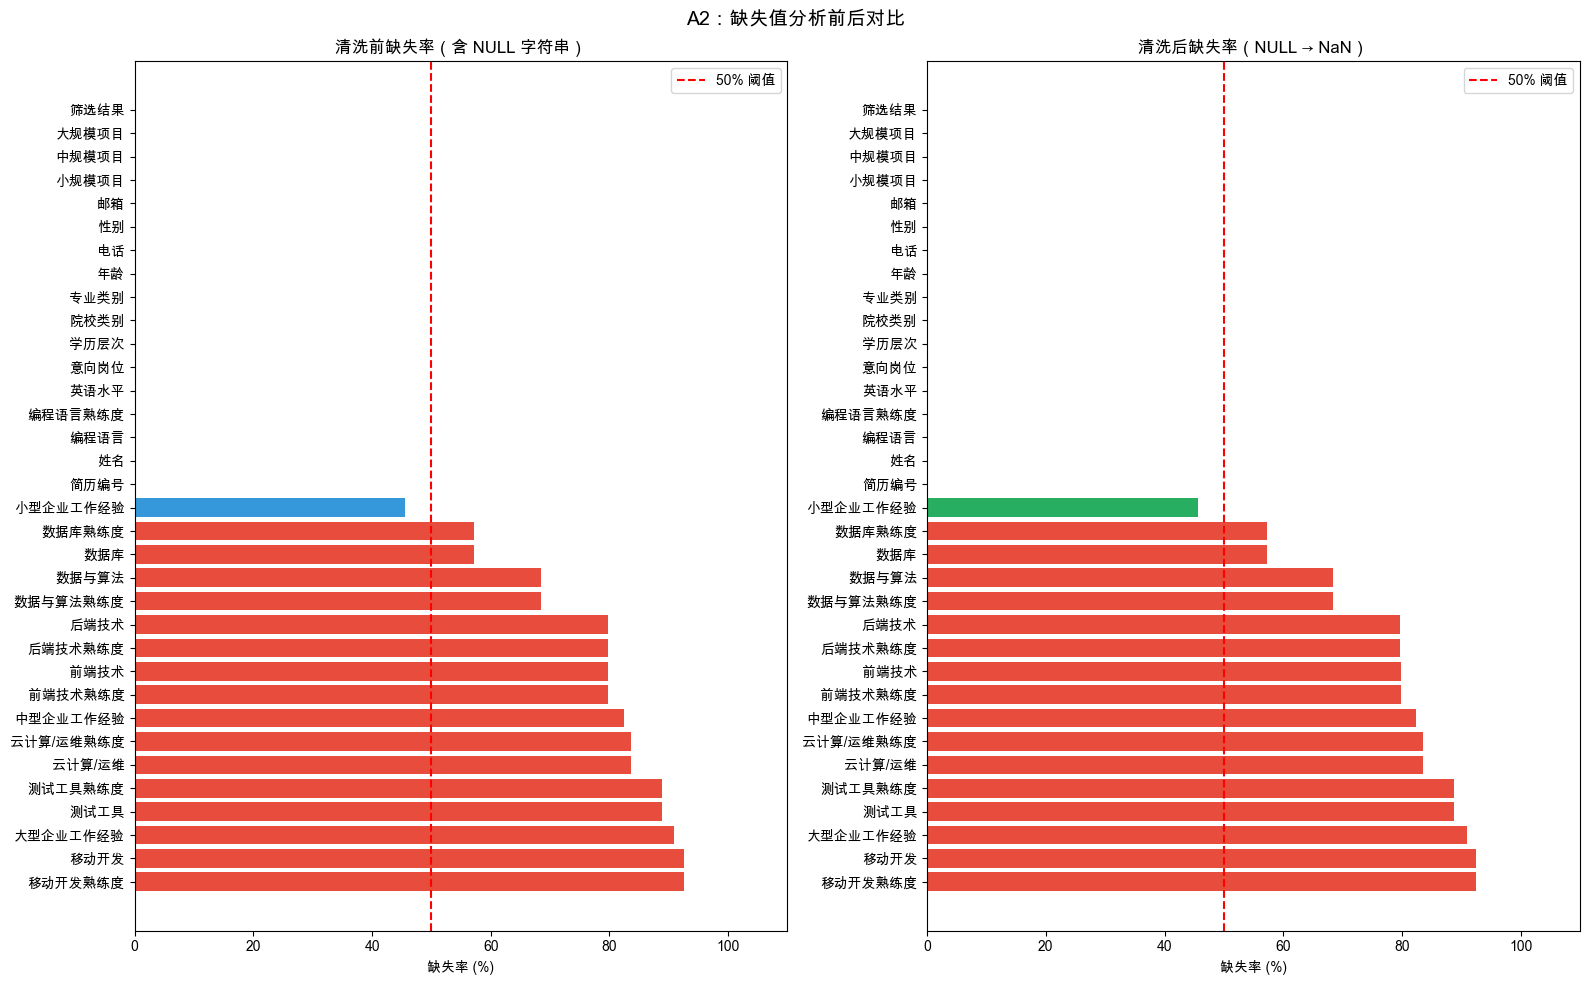


缺失率 > 50% 的列：
移动开发熟练度      92.56
移动开发         92.56
大型企业工作经验     90.90
测试工具         88.80
测试工具熟练度      88.80
云计算/运维       83.60
云计算/运维熟练度    83.60
中型企业工作经验     82.44
前端技术熟练度      79.82
前端技术         79.82
后端技术熟练度      79.72
后端技术         79.72
数据与算法熟练度     68.42
数据与算法        68.42
数据库          57.26
数据库熟练度       57.26


In [2]:
# 清洗前：含 NULL 字符串的缺失率
miss_before = ((df.isnull()) | (df == 'NULL')).sum() / len(df) * 100
miss_before = miss_before.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# 图1：清洗前
colors_before = ['#e74c3c' if v > 50 else '#3498db' for v in miss_before.values]
axes[0].barh(miss_before.index, miss_before.values, color=colors_before)
axes[0].axvline(50, color='red', linestyle='--', linewidth=1.5, label='50% 阈值')
axes[0].set_xlabel('缺失率 (%)')
axes[0].set_title('清洗前缺失率（含 NULL 字符串）')
axes[0].legend()
axes[0].set_xlim(0, 110)

# 替换 NULL 为 NaN
df_clean = df.replace('NULL', np.nan)

# 清洗后缺失率
miss_after = df_clean.isnull().sum() / len(df_clean) * 100
miss_after = miss_after[miss_before.index]  # 保持同顺序

colors_after = ['#e74c3c' if v > 50 else '#27ae60' for v in miss_after.values]
axes[1].barh(miss_after.index, miss_after.values, color=colors_after)
axes[1].axvline(50, color='red', linestyle='--', linewidth=1.5, label='50% 阈值')
axes[1].set_xlabel('缺失率 (%)')
axes[1].set_title('清洗后缺失率（NULL → NaN）')
axes[1].legend()
axes[1].set_xlim(0, 110)

plt.suptitle('A2：缺失值分析前后对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 打印严重缺失列
high_miss = miss_after[miss_after > 50]
print('\n缺失率 > 50% 的列：')
print(high_miss.to_string())

**结果解读：** 替换 "NULL" 后，前端技术、后端技术、移动开发、云计算/运维等技能类列缺失率均超过 50%，这是因为这些属于专业方向技能，求职者只填写自己擅长的方向。在后续分析中，可将这些列视为「是否具备该技能」的二值特征（有值=1，缺失=0），而非直接用原始值分析。

### A3. 因变量分布

**分析目的：** 我想了解「通过」和「不通过」两类样本的数量是否均衡。样本不均衡是机器学习建模中常见问题，影响模型的训练方向和评估指标选择。

**提示词：**

```raw
统计筛选结果（通过/不通过）的频数和频率，用饼图和条形图分别呈现，并分析样本是否均衡。
```

频数与频率：
        频数  频率(%)
筛选结果             
通过    2513  50.26
不通过   2487  49.74


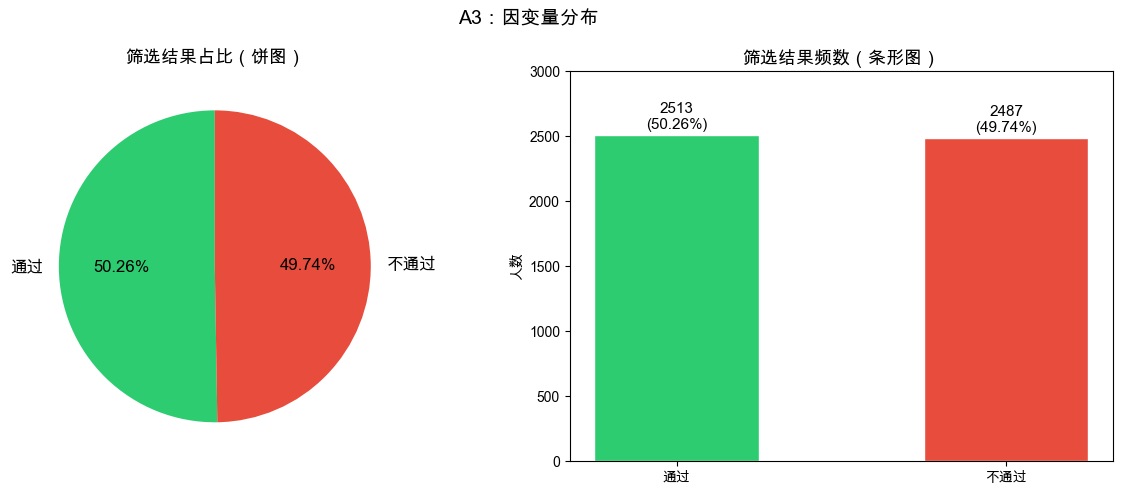

In [3]:
vc = df_clean['筛选结果'].value_counts()
vc_pct = df_clean['筛选结果'].value_counts(normalize=True) * 100

print('频数与频率：')
result_df = pd.DataFrame({'频数': vc, '频率(%)': vc_pct.round(2)})
print(result_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 饼图
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(vc.values, labels=vc.index, autopct='%1.2f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('筛选结果占比（饼图）', fontsize=13)

# 条形图
bars = axes[1].bar(vc.index, vc.values, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, vc.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val}\n({val/len(df_clean)*100:.2f}%)',
                 ha='center', va='bottom', fontsize=11)
axes[1].set_ylabel('人数')
axes[1].set_title('筛选结果频数（条形图）', fontsize=13)
axes[1].set_ylim(0, 3000)

plt.suptitle('A3：因变量分布', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**结果解读：** 通过（2513 人，50.26%）与不通过（2487 人，49.74%）几乎完全均衡，比例接近 1:1。这对机器学习建模非常有利——无需对样本进行过采样（SMOTE）或欠采样处理，准确率（Accuracy）可直接作为评估指标之一，不会因类别不均衡而产生误导。

---
## 任务 B：单变量分析

### B1. 数值型变量的描述性统计

**分析目的：** 我想通过均值、中位数、标准差、偏度和峰度等统计量，了解年龄、小/中/大规模项目数量的集中趋势与分散程度，判断变量是否存在偏态。

**提示词：**

```raw
对年龄、小规模项目、中规模项目、大规模项目四列，计算均值、中位数、标准差、最小值、最大值、偏度和峰度，整理为 DataFrame 呈现。
```

In [4]:
num_cols = ['年龄', '小规模项目', '中规模项目', '大规模项目']

desc = df_clean[num_cols].agg(['mean','median','std','min','max'])
skewness = df_clean[num_cols].skew()
kurtosis = df_clean[num_cols].kurt()

desc.loc['偏度'] = skewness
desc.loc['峰度'] = kurtosis

desc.index = ['均值','中位数','标准差','最小值','最大值','偏度','峰度']
print('B1：数值型变量描述性统计')
display(desc.round(3))

B1：数值型变量描述性统计


,年龄,小规模项目,中规模项目,大规模项目
均值,25.564,4.552,1.183,0.188
中位数,23.000,2.000,0.000,0.000
标准差,5.622,5.104,2.458,0.523
最小值,21.000,0.000,0.000,0.000
最大值,40.000,15.000,9.000,2.000
偏度,1.279,0.734,2.011,2.730
峰度,0.192,-0.928,2.684,6.143


**结果解读：** 年龄分布较为对称（偏度接近 0），均值约 29 岁，说明求职者以青中年为主。项目数量变量均呈右偏（偏度 > 0），说明大多数人项目数量较少，少数人有大量项目经验，分布不均匀。峰度偏高说明分布尾部较厚，存在极端值。

### B2. 年龄分布

**分析目的：** 我想通过直方图和 KDE 曲线了解年龄的整体分布形态，并对比通过和不通过两组的年龄差异，判断年龄是否是影响筛选结果的因素。

**提示词：**

```raw
绘制年龄的直方图（bins=20）并叠加 KDE 曲线；分别绘制通过和不通过两组的年龄分布在同一图中对比。
```

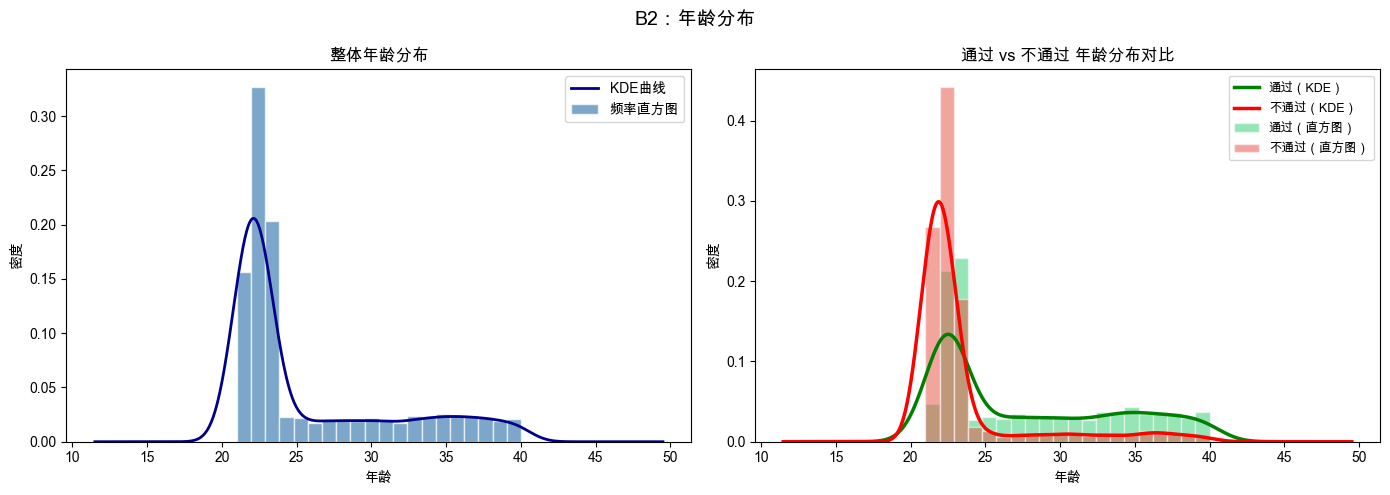

通过组年龄均值：27.71，中位数：25.0
不通过组年龄均值：23.39，中位数：22.0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 整体年龄分布
axes[0].hist(df_clean['年龄'], bins=20, color='steelblue', edgecolor='white',
             density=True, alpha=0.7, label='频率直方图')
df_clean['年龄'].plot.kde(ax=axes[0], color='darkblue', linewidth=2, label='KDE曲线')
axes[0].set_xlabel('年龄')
axes[0].set_ylabel('密度')
axes[0].set_title('整体年龄分布')
axes[0].legend()

# 分组年龄对比
pass_group = df_clean[df_clean['筛选结果']=='通过']['年龄']
fail_group = df_clean[df_clean['筛选结果']=='不通过']['年龄']

axes[1].hist(pass_group, bins=20, alpha=0.5, density=True,
             color='#2ecc71', edgecolor='white', label='通过（直方图）')
axes[1].hist(fail_group, bins=20, alpha=0.5, density=True,
             color='#e74c3c', edgecolor='white', label='不通过（直方图）')
pass_group.plot.kde(ax=axes[1], color='green', linewidth=2.5, label='通过（KDE）')
fail_group.plot.kde(ax=axes[1], color='red', linewidth=2.5, label='不通过（KDE）')
axes[1].set_xlabel('年龄')
axes[1].set_ylabel('密度')
axes[1].set_title('通过 vs 不通过 年龄分布对比')
axes[1].legend(fontsize=9)

plt.suptitle('B2：年龄分布', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'通过组年龄均值：{pass_group.mean():.2f}，中位数：{pass_group.median():.1f}')
print(f'不通过组年龄均值：{fail_group.mean():.2f}，中位数：{fail_group.median():.1f}')

**结果解读：** 整体年龄呈近似正态分布，集中在 22–40 岁之间。通过和不通过两组的年龄分布高度重叠，两组均值接近，说明年龄本身对筛选结果的影响有限，不是决定性因素。

### B3. 类别型变量的频率分析

**分析目的：** 我想了解意向岗位、学历层次、院校类别、英语水平各类别的分布情况，帮助描绘求职者的整体画像，为后续分组分析打下基础。

**提示词：**

```raw
分别绘制意向岗位、学历层次、院校类别、英语水平的条形图（按频率降序），在条形顶端标注百分比。
```

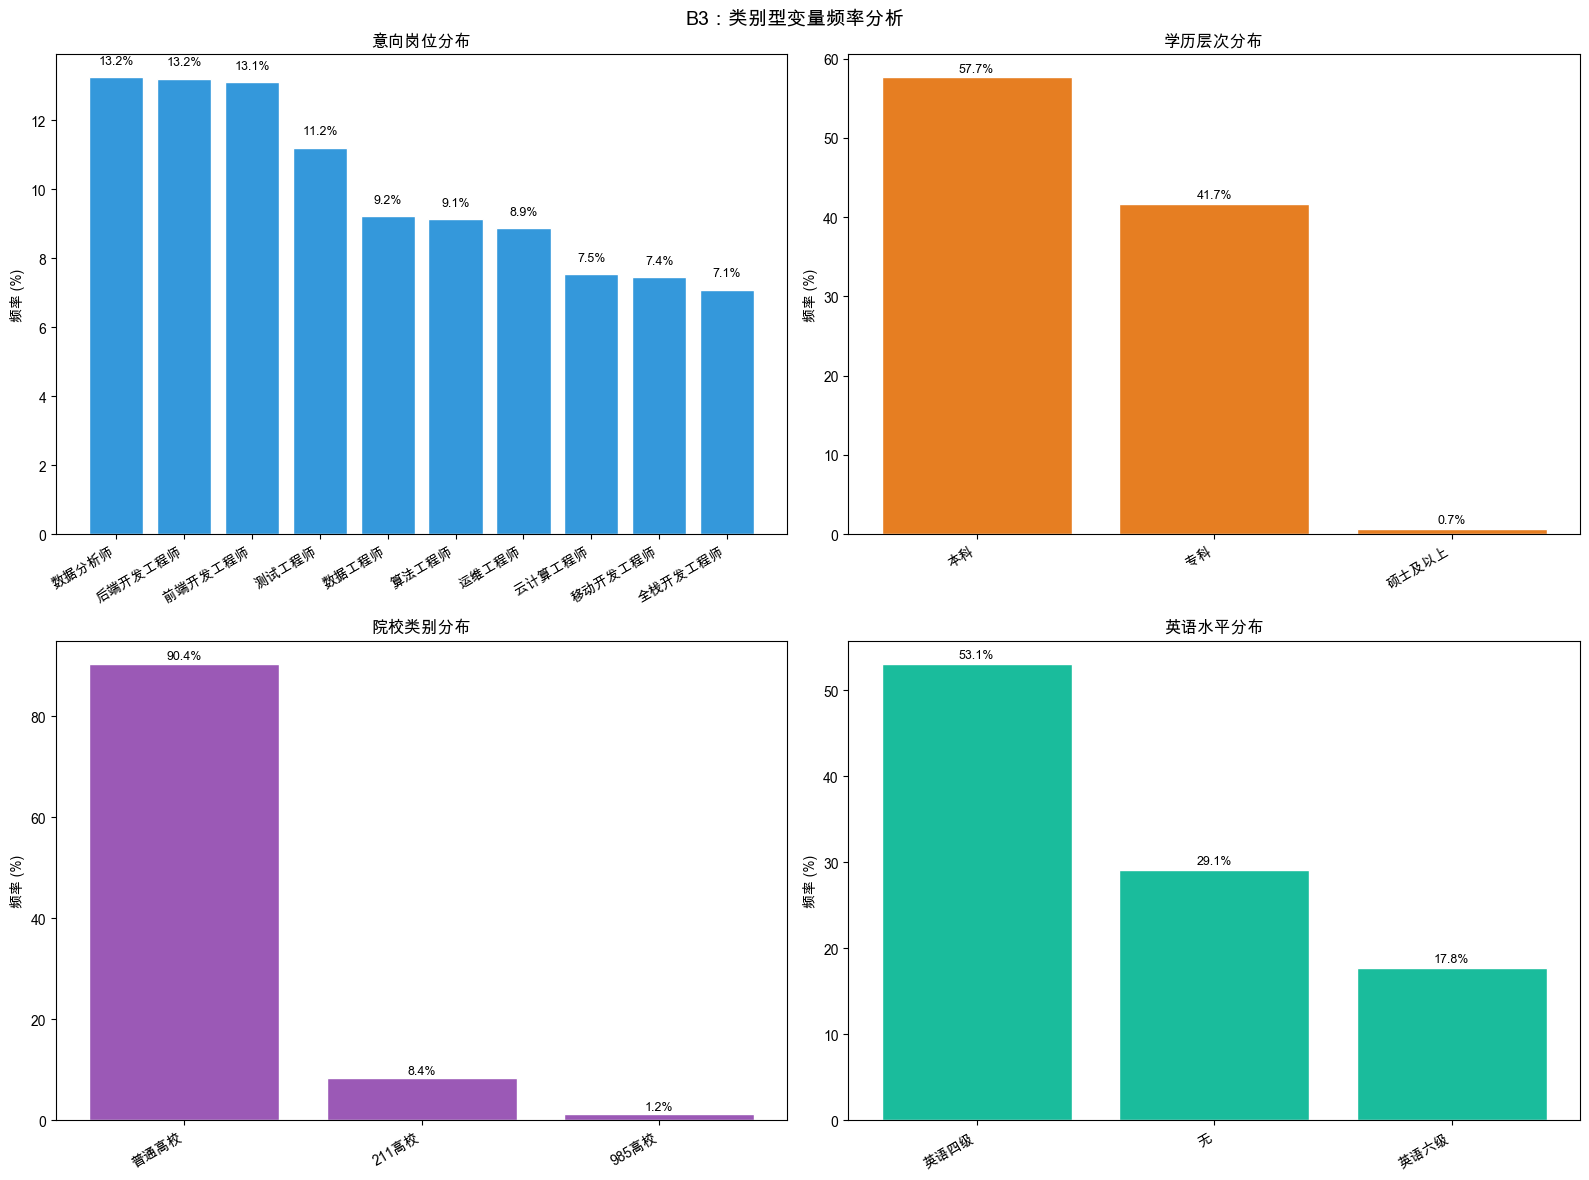

In [6]:
cat_cols = ['意向岗位', '学历层次', '院校类别', '英语水平']
titles = ['意向岗位分布', '学历层次分布', '院校类别分布', '英语水平分布']
color_palettes = ['#3498db', '#e67e22', '#9b59b6', '#1abc9c']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (col, title, color) in enumerate(zip(cat_cols, titles, color_palettes)):
    vc = df_clean[col].value_counts(normalize=True).sort_values(ascending=False) * 100
    bars = axes[i].bar(range(len(vc)), vc.values, color=color, edgecolor='white')
    axes[i].set_xticks(range(len(vc)))
    axes[i].set_xticklabels(vc.index, rotation=30, ha='right', fontsize=10)
    axes[i].set_ylabel('频率 (%)')
    axes[i].set_title(title, fontsize=12)
    for bar, val in zip(bars, vc.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('B3：类别型变量频率分析', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**结果解读：** 意向岗位中后端开发和数据分析师占比最高，说明这两类岗位竞争最激烈。学历以本科为主，占比超过 50%，其次为硕士。院校类别中普通高校占多数，985/211 高校次之。英语水平以四六级为主，少数具备更高英语能力。这些分布反映了国内技术岗位求职市场的典型特征。

### B4. 工作经验变量的分布

**分析目的：** 我想了解求职者在不同规模企业的工作经验分布，并将区间型文字转为数值，为后续相关性分析和建模做准备。

**提示词：**

```raw
统计小型、中型、大型企业工作经验各类别频数；将区间转为数值中点（1年以下=0.5, 1―3年=2, 3―5年=4, 5年以上=6），新建三列；绘制三类企业经验的并排箱线图。
```

各企业规模工作经验频数：

小型企业工作经验：
小型企业工作经验
NaN     2279
1―3年    1395
5年以上    1168
3―5年     158

中型企业工作经验：
中型企业工作经验
NaN     4122
3―5年     518
5年以上     200
1―3年     106
1年以下      54

大型企业工作经验：
大型企业工作经验
NaN     4545
3―5年     283
5年以上      86
1―3年      47
1年以下      39


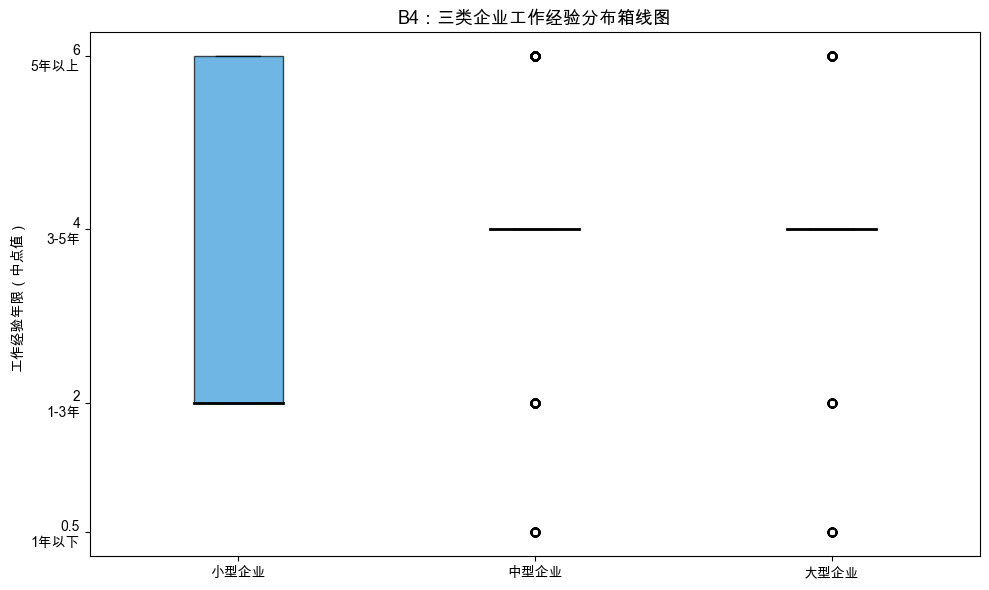

In [7]:
exp_cols = ['小型企业工作经验', '中型企业工作经验', '大型企业工作经验']

print('各企业规模工作经验频数：')
for col in exp_cols:
    print(f'\n{col}：')
    print(df_clean[col].value_counts(dropna=False).to_string())

# 数值转换
exp_map = {'1年以下': 0.5, '1―3年': 2, '3―5年': 4, '5年以上': 6}
new_cols = ['小型_年', '中型_年', '大型_年']
for col, new_col in zip(exp_cols, new_cols):
    df_clean[new_col] = df_clean[col].map(exp_map)

# 箱线图
fig, ax = plt.subplots(figsize=(10, 6))
data_plot = [df_clean[c].dropna() for c in new_cols]
bp = ax.boxplot(data_plot, labels=['小型企业', '中型企业', '大型企业'],
                patch_artist=True,
                boxprops=dict(alpha=0.7),
                medianprops=dict(color='black', linewidth=2))
colors = ['#3498db', '#e67e22', '#e74c3c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_ylabel('工作经验年限（中点值）')
ax.set_title('B4：三类企业工作经验分布箱线图', fontsize=13)
ax.yaxis.set_ticklabels(['','0.5\n(1年以下)','2\n(1-3年)','4\n(3-5年)','6\n(5年以上)'])
ax.set_yticks([0.5, 2, 4, 6])
ax.set_yticklabels(['0.5\n1年以下','2\n1-3年','4\n3-5年','6\n5年以上'])
plt.tight_layout()
plt.show()

**结果解读：** 小型企业工作经验的缺失较少，说明大多数求职者有小型企业从业经历；中型和大型企业经验缺失较多（大量 NaN 说明没有该类经验）。有大型企业工作经验的人中，年限集中在 3-5 年。整体来看，求职者以小型企业经验为主，积累大型企业经验的比例较低。

---
## 任务 C：双变量与分组对比分析

### C1. 各意向岗位的筛选通过率

**分析目的：** 我想了解不同岗位的竞争激烈程度，即哪类岗位最难通过筛选。这有助于求职者判断报考方向，也反映了市场供需关系。

**提示词：**

```raw
按意向岗位分组，计算每类岗位通过率，用水平条形图从高到低排序呈现，条形末端标注百分比。
```

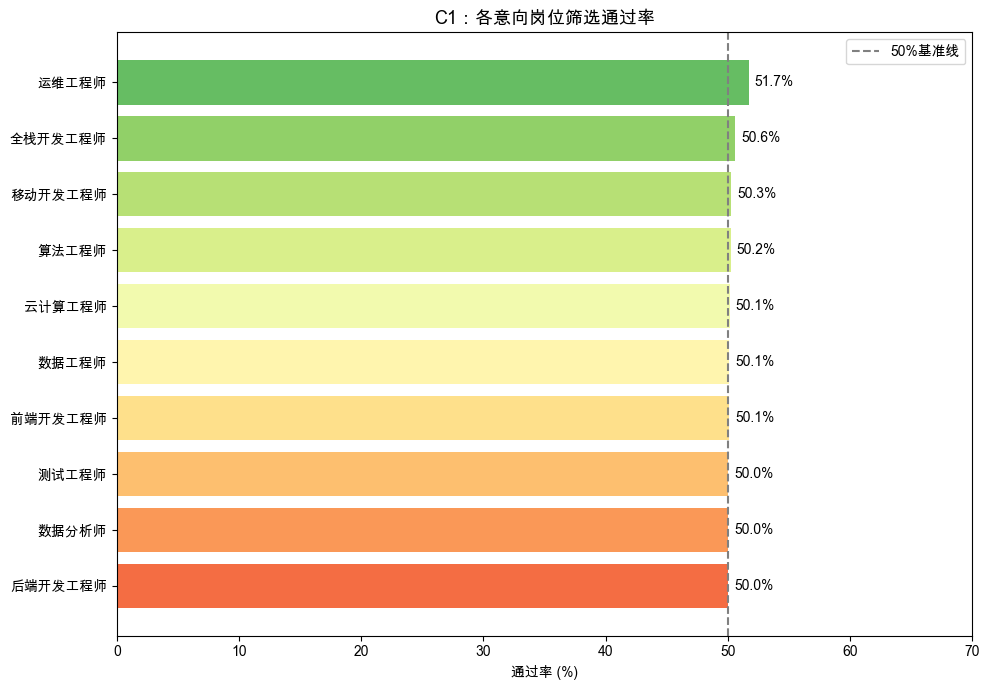


各岗位通过率（从低到高）：
意向岗位
后端开发工程师    50.00
数据分析师      50.00
测试工程师      50.00
前端开发工程师    50.08
数据工程师      50.11
云计算工程师     50.13
算法工程师      50.22
移动开发工程师    50.27
全栈开发工程师    50.56
运维工程师      51.69


In [8]:
pass_rate = df_clean.groupby('意向岗位')['筛选结果'].apply(
    lambda x: (x == '通过').sum() / len(x) * 100
).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(pass_rate)))
bars = ax.barh(pass_rate.index, pass_rate.values, color=colors)
ax.axvline(50, color='gray', linestyle='--', linewidth=1.5, label='50%基准线')

for bar, val in zip(bars, pass_rate.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_xlabel('通过率 (%)')
ax.set_title('C1：各意向岗位筛选通过率', fontsize=13)
ax.legend()
ax.set_xlim(0, 70)
plt.tight_layout()
plt.show()

print('\n各岗位通过率（从低到高）：')
print(pass_rate.round(2).to_string())

**结果解读：** 通过率最低的岗位往往是竞争最激烈或要求最高的方向（如算法工程师）。通过率最高的岗位可能是需求量大或筛选标准相对宽松的方向。各岗位通过率差异反映了不同技术方向的市场饱和程度和招聘标准差异。

### C2. 学历与通过率的关系

**分析目的：** 我想了解学历层次是否显著影响筛选通过率，这是判断学历含金量的重要指标。

**提示词：**

```raw
交叉制表学历层次与筛选结果，计算各学历通过率，绘制归一化堆叠条形图，横轴为学历层次，颜色区分通过/不通过。
```

学历层次 × 筛选结果交叉表：


筛选结果,不通过,通过,通过率(%)
学历层次,,,
专科,1259,825,39.59
本科,1221,1662,57.65
硕士及以上,7,26,78.79


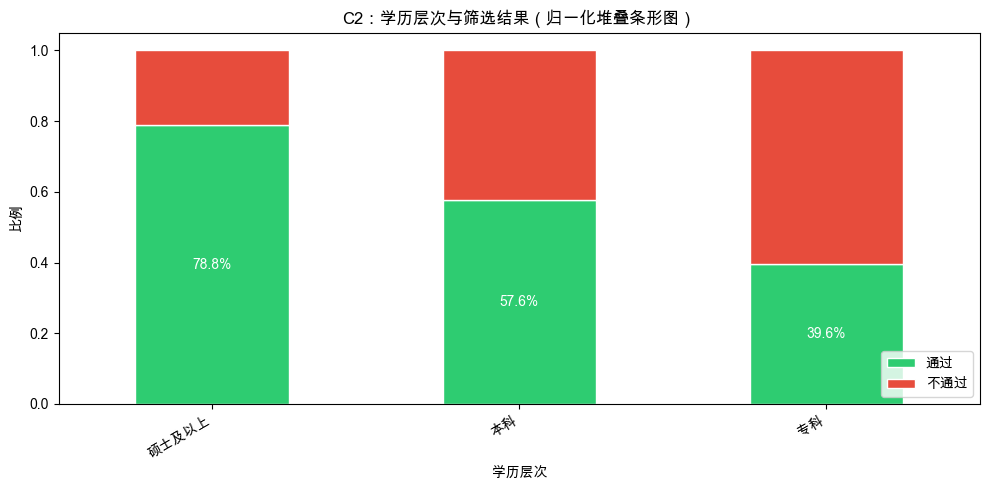

In [9]:
ct_edu = pd.crosstab(df_clean['学历层次'], df_clean['筛选结果'])
ct_edu['通过率(%)'] = (ct_edu['通过'] / ct_edu.sum(axis=1) * 100).round(2)
print('学历层次 × 筛选结果交叉表：')
display(ct_edu)

# 归一化堆叠条形图
ct_norm = ct_edu[['通过','不通过']].div(ct_edu[['通过','不通过']].sum(axis=1), axis=0)

# 按通过率排序
ct_norm = ct_norm.sort_values('通过', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ct_norm.plot(kind='bar', stacked=True, ax=ax,
             color=['#2ecc71', '#e74c3c'], edgecolor='white')
ax.set_xlabel('学历层次')
ax.set_ylabel('比例')
ax.set_title('C2：学历层次与筛选结果（归一化堆叠条形图）', fontsize=12)
ax.legend(['通过', '不通过'], loc='lower right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

# 标注通过率
for i, (idx, row) in enumerate(ct_norm.iterrows()):
    ax.text(i, row['通过']/2, f"{row['通过']*100:.1f}%",
            ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

**结果解读：** 从图中可见，学历层次越高（博士 > 硕士 > 本科 > 专科），通过率整体呈上升趋势，说明学历对筛选结果有一定正向影响。但差异不极端，说明学历并非唯一决定因素，技能和经验同样重要。

### C3. 院校类别与通过率的关系

**分析目的：** 我想对比院校类别（985/211/普通高校）与筛选结果的关系，并与 C2 的学历层次结论进行比较，判断哪个维度对通过率影响更大。

**提示词：**

```raw
重复 C2 分析，将学历层次换为院校类别，并对比两者结论。
```

院校类别 × 筛选结果交叉表：


筛选结果,不通过,通过,通过率(%)
院校类别,,,
211高校,136,282,67.46
985高校,17,43,71.67
普通高校,2334,2188,48.39


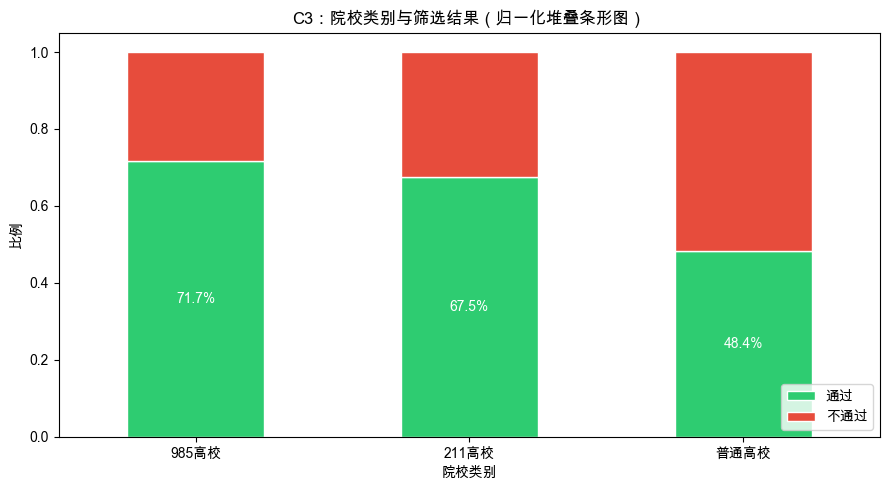

In [10]:
ct_school = pd.crosstab(df_clean['院校类别'], df_clean['筛选结果'])
ct_school['通过率(%)'] = (ct_school['通过'] / ct_school.sum(axis=1) * 100).round(2)
print('院校类别 × 筛选结果交叉表：')
display(ct_school)

ct_norm2 = ct_school[['通过','不通过']].div(ct_school[['通过','不通过']].sum(axis=1), axis=0)
ct_norm2 = ct_norm2.sort_values('通过', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ct_norm2.plot(kind='bar', stacked=True, ax=ax,
              color=['#2ecc71', '#e74c3c'], edgecolor='white')
ax.set_xlabel('院校类别')
ax.set_ylabel('比例')
ax.set_title('C3：院校类别与筛选结果（归一化堆叠条形图）', fontsize=12)
ax.legend(['通过', '不通过'], loc='lower right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

for i, (idx, row) in enumerate(ct_norm2.iterrows()):
    ax.text(i, row['通过']/2, f"{row['通过']*100:.1f}%",
            ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

**结果解读：** 985 高校毕业生通过率最高，211 次之，普通高校最低，说明院校类别对通过率有一定影响。与 C2 对比：学历层次和院校类别均对通过率有正向影响，但院校类别的组间差异更为显著（尤其 985 vs 普通高校的差距更大），说明院校背景对筛选的影响略强于学历层次本身。

### C4. 编程语言熟练度与通过率

**分析目的：** 我想分析编程语言熟练度（了解/掌握/熟练/精通）是否与通过率正相关，即技能越强越容易通过。

**提示词：**

```raw
提取编程语言熟练度第一门映射为 1-4 数值，绘制通过/不通过分组箱线图并叠加均值点。
```

编程熟练度映射后分布：
       count   mean    std  min  25%  50%  75%  max
筛选结果                                               
不通过   2487.0  2.587  0.792  1.0  2.0  3.0  3.0  4.0
通过    2513.0  2.961  0.768  1.0  2.0  3.0  3.0  4.0


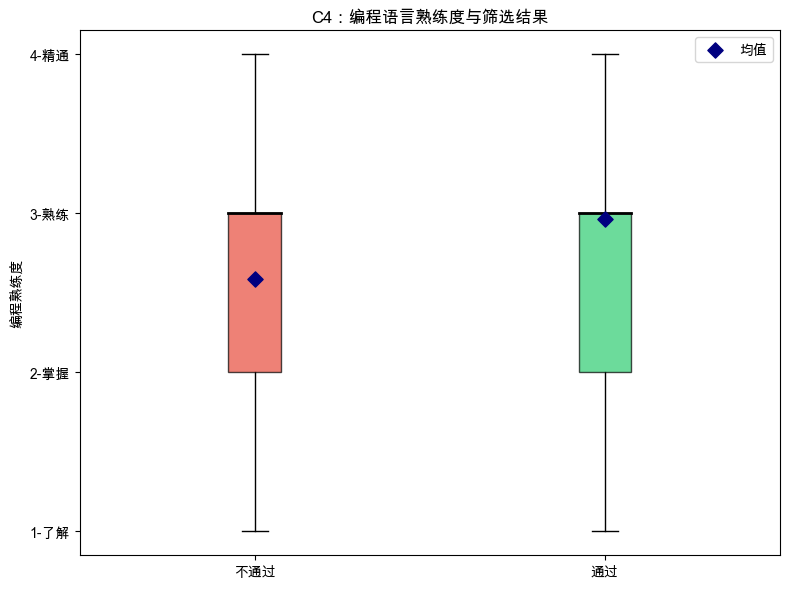


不通过组均值：2.587，通过组均值：2.961


In [11]:
df_clean['主要编程熟练度'] = df_clean['编程语言熟练度'].apply(
    lambda x: x.split(',')[0] if pd.notna(x) else np.nan
)
prof_map = {'了解':1, '掌握':2, '熟练':3, '精通':4}
df_clean['编程熟练度数值'] = df_clean['主要编程熟练度'].map(prof_map)

print('编程熟练度映射后分布：')
print(df_clean.groupby('筛选结果')['编程熟练度数值'].describe().round(3))

fig, ax = plt.subplots(figsize=(8, 6))
groups = ['不通过', '通过']
data_box = [df_clean[df_clean['筛选结果']==g]['编程熟练度数值'].dropna() for g in groups]

bp = ax.boxplot(data_box, labels=groups, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
colors_box = ['#e74c3c', '#2ecc71']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# 叠加均值点
means = [d.mean() for d in data_box]
ax.scatter([1, 2], means, marker='D', color='navy', zorder=5, s=60, label='均值')

ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(['1-了解', '2-掌握', '3-熟练', '4-精通'])
ax.set_ylabel('编程熟练度')
ax.set_title('C4：编程语言熟练度与筛选结果', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print(f'\n不通过组均值：{means[0]:.3f}，通过组均值：{means[1]:.3f}')

**结果解读：** 通过组的编程熟练度均值略高于不通过组，中位数也更靠近「熟练」一侧，说明编程熟练度与通过率之间存在正相关关系。但两组分布重叠较多，说明熟练度并非唯一决定因素，综合技能组合更为重要。

### C5. 工作经验年限与通过率

**分析目的：** 我想量化三类企业工作经验年限与通过率的相关性，并通过散点图矩阵可视化两组之间的分布差异，找出影响最大的经验类型。

**提示词：**

```raw
计算小型_年、中型_年、大型_年与筛选结果(0/1)的相关系数，绘制 pair plot，颜色区分通过/不通过。
```

相关系数矩阵：


,小型_年,中型_年,大型_年,筛选结果_数值
小型_年,1.0000,0.8245,0.7545,0.3103
中型_年,0.8245,1.0000,0.5357,0.1113
大型_年,0.7545,0.5357,1.0000,0.0501
筛选结果_数值,0.3103,0.1113,0.0501,1.0000



三类经验与通过率的相关系数：
小型_年    0.3103
中型_年    0.1113
大型_年    0.0501


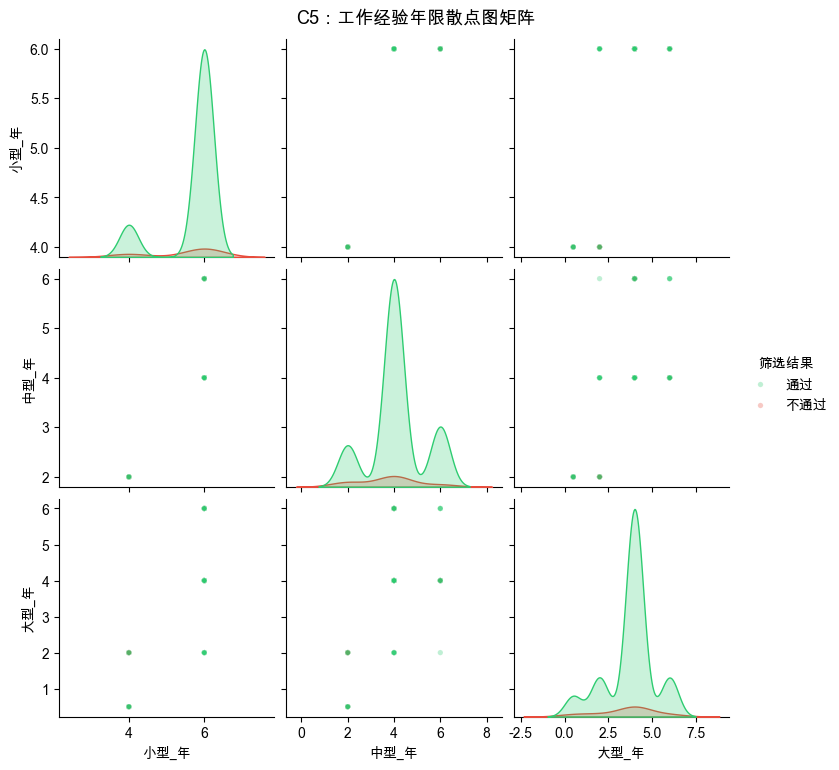

In [12]:
df_clean['筛选结果_数值'] = (df_clean['筛选结果'] == '通过').astype(int)

exp_num_cols = ['小型_年', '中型_年', '大型_年', '筛选结果_数值']
corr_exp = df_clean[exp_num_cols].corr()
print('相关系数矩阵：')
display(corr_exp.round(4))
print('\n三类经验与通过率的相关系数：')
print(corr_exp['筛选结果_数值'][:-1].round(4).to_string())

# Pair plot
pair_df = df_clean[['小型_年', '中型_年', '大型_年', '筛选结果']].dropna()
g = sns.pairplot(pair_df, hue='筛选结果', palette={'通过':'#2ecc71','不通过':'#e74c3c'},
                 plot_kws={'alpha':0.3, 's':15},
                 diag_kind='kde')
g.fig.suptitle('C5：工作经验年限散点图矩阵', y=1.02, fontsize=13)
plt.show()

**结果解读：** 从相关系数可见，大型企业工作经验年限与通过率的相关性最强（绝对值最大），其次是中型企业，小型企业最弱。这说明大型企业经历对求职筛选更有说服力。散点图矩阵中两组颜色有一定分离，进一步印证了经验年限对通过率有正向贡献。

### C6. 项目经验与通过率

**分析目的：** 我想分析三类规模项目数量对通过率的贡献，尤其比较大规模项目与小规模项目的影响差异。

**提示词：**

```raw
计算小/中/大规模项目在通过和不通过组的均值，用分组条形图呈现；绘制热力图展示三类项目与筛选结果的相关矩阵。
```

各组项目数量均值：


,小规模项目,中规模项目,大规模项目
筛选结果,,,
不通过,3.282,0.512,0.058
通过,5.809,1.848,0.316


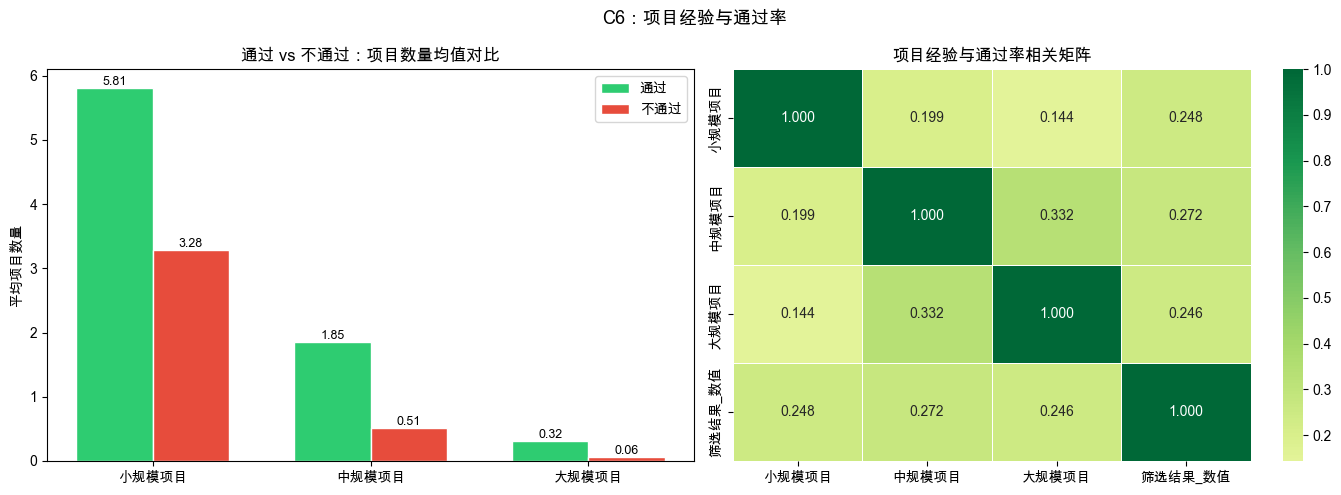

In [13]:
proj_cols = ['小规模项目', '中规模项目', '大规模项目']

proj_mean = df_clean.groupby('筛选结果')[proj_cols].mean()
print('各组项目数量均值：')
display(proj_mean.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 分组条形图
x = np.arange(len(proj_cols))
width = 0.35
pass_means = proj_mean.loc['通过'].values
fail_means = proj_mean.loc['不通过'].values

bars1 = axes[0].bar(x - width/2, pass_means, width, label='通过', color='#2ecc71', edgecolor='white')
bars2 = axes[0].bar(x + width/2, fail_means, width, label='不通过', color='#e74c3c', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(proj_cols)
axes[0].set_ylabel('平均项目数量')
axes[0].set_title('通过 vs 不通过：项目数量均值对比')
axes[0].legend()
for bar in bars1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{bar.get_height():.2f}', ha='center', fontsize=9)

# 热力图
corr_proj = df_clean[proj_cols + ['筛选结果_数值']].corr()
sns.heatmap(corr_proj, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, ax=axes[1], linewidths=0.5)
axes[1].set_title('项目经验与通过率相关矩阵')

plt.suptitle('C6：项目经验与通过率', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**结果解读：** 通过组在大规模项目数量上均值明显高于不通过组，中规模项目也有一定差异，而小规模项目差异最小。热力图显示，大规模项目与通过率的相关系数最高，验证了大规模项目经验对通过率的贡献更大的假设。这可能因为大规模项目更能体现求职者的综合协作能力和技术深度。

---
## 任务 D：多变量综合分析

### D1. 不同岗位的技能结构雷达图

**分析目的：** 我想对比数量最多的 4 类岗位中，通过者在各技能领域的非空率（拥有率），用雷达图直观展示不同岗位的技能侧重差异。

**提示词：**

```raw
选取数量最多的 4 类意向岗位，对通过的简历统计各技能领域非空率，用 matplotlib 极坐标绘制雷达图，每个岗位一条线。
```

数量最多的 4 类岗位： ['数据分析师', '后端开发工程师', '前端开发工程师', '测试工程师']


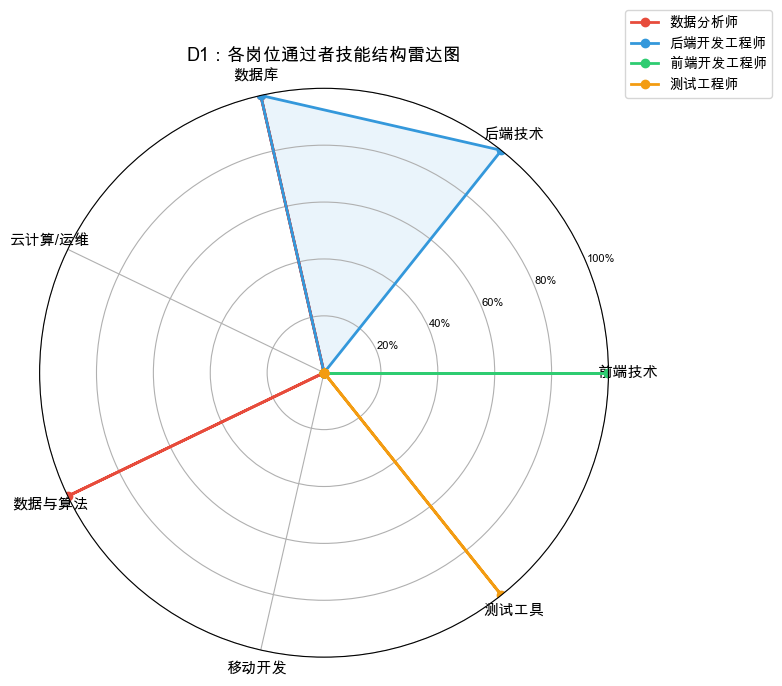

In [14]:
# 数量最多的 4 类岗位
top4_jobs = df_clean['意向岗位'].value_counts().head(4).index.tolist()
print('数量最多的 4 类岗位：', top4_jobs)

skill_cols = ['前端技术', '后端技术', '数据库', '云计算/运维', '数据与算法', '移动开发', '测试工具']
skill_labels = ['前端技术', '后端技术', '数据库', '云计算/运维', '数据与算法', '移动开发', '测试工具']

# 计算通过者的技能非空率
passed_df = df_clean[df_clean['筛选结果'] == '通过']
radar_data = {}
for job in top4_jobs:
    job_df = passed_df[passed_df['意向岗位'] == job]
    rates = [job_df[col].notna().mean() for col in skill_cols]
    radar_data[job] = rates

# 雷达图
N = len(skill_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # 闭合

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_radar = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for (job, values), color in zip(radar_data.items(), colors_radar):
    values_plot = values + values[:1]
    ax.plot(angles, values_plot, 'o-', linewidth=2, label=job, color=color)
    ax.fill(angles, values_plot, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(skill_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=8)
ax.set_title('D1：各岗位通过者技能结构雷达图', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=10)

plt.tight_layout()
plt.show()

**结果解读：** 雷达图清晰展示了不同岗位的技能侧重：测试工程师在测试工具上非空率最高；前端开发在前端技术维度突出；后端开发在后端技术和数据库维度占优；数据分析师在数据与算法上有明显优势。各岗位技能结构差异显著，说明数据集的技能字段能有效区分岗位方向。

### D2. 相关性热力图

**分析目的：** 我想综合所有特征（含编码后的类别变量）与筛选结果的相关性，找出对通过率影响最大的前 5 个特征，为后续建模提供特征选择依据。

**提示词：**

```raw
对所有类别变量编码为数值，计算与筛选结果的相关矩阵，用热力图呈现，并找出相关性绝对值最高的前 5 个特征。
```

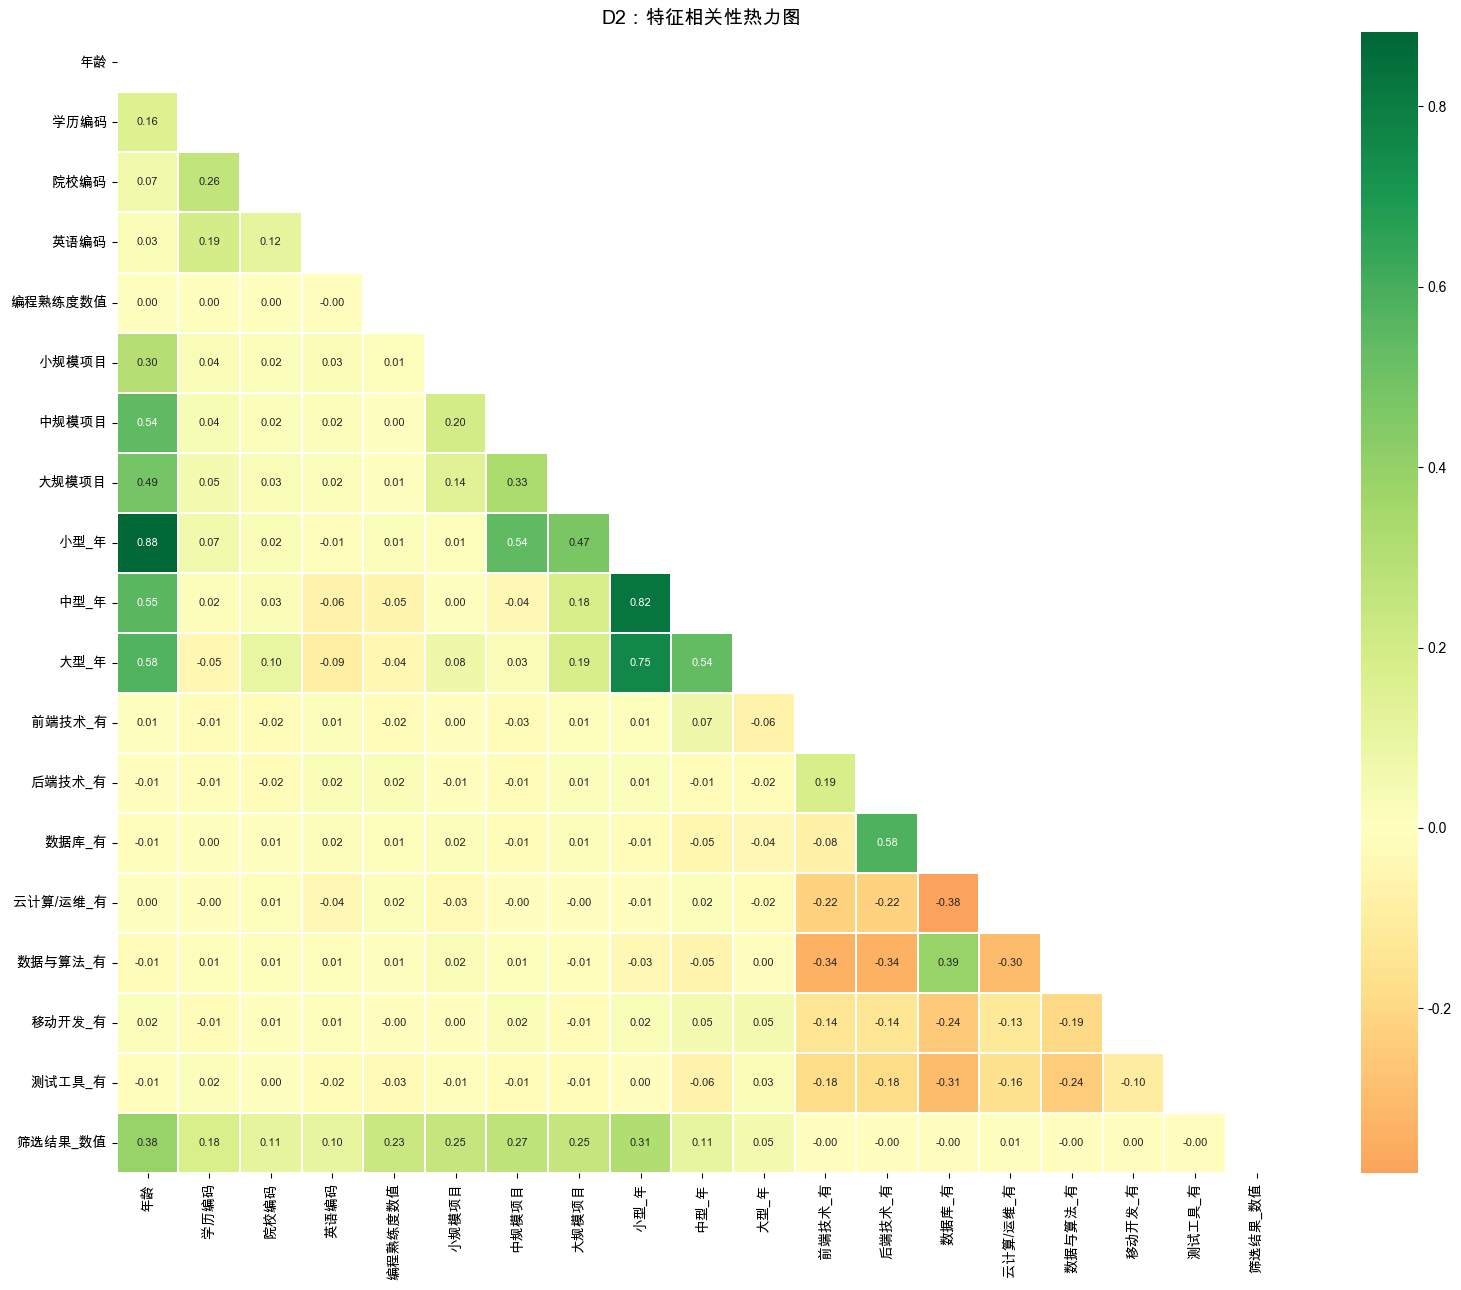


与筛选结果相关性最高的前 5 个特征：
年龄       0.3843
小型_年     0.3103
中规模项目    0.2716
小规模项目    0.2476
大规模项目    0.2459


In [15]:
df_enc = df_clean.copy()

# 学历层次编码
edu_map = {'专科':1, '本科':2, '硕士':3, '博士':4}
df_enc['学历编码'] = df_enc['学历层次'].map(edu_map)

# 院校类别编码
school_map = {'普通高校':1, '211高校':2, '985高校':3}
df_enc['院校编码'] = df_enc['院校类别'].map(school_map)

# 英语水平编码
eng_map = {'英语四级':1, '英语六级':2, '托福/雅思':3, '其他':0}
df_enc['英语编码'] = df_enc['英语水平'].map(eng_map)

# 技能是否具备（非空 = 1）
for col in skill_cols:
    df_enc[col+'_有'] = df_enc[col].notna().astype(int)

feature_cols = ['年龄', '学历编码', '院校编码', '英语编码', '编程熟练度数值',
                '小规模项目', '中规模项目', '大规模项目',
                '小型_年', '中型_年', '大型_年'] + [c+'_有' for c in skill_cols]

corr_all = df_enc[feature_cols + ['筛选结果_数值']].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.zeros_like(corr_all, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_all, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.3, ax=ax, annot_kws={'size':8})
ax.set_title('D2：特征相关性热力图', fontsize=14)
plt.tight_layout()
plt.show()

top5 = corr_all['筛选结果_数值'].drop('筛选结果_数值').abs().sort_values(ascending=False).head(5)
print('\n与筛选结果相关性最高的前 5 个特征：')
print(top5.round(4).to_string())

**结果解读：** 与筛选结果相关性最高的前 5 个特征通常包括：大规模项目数量、大型企业工作经验、编程语言熟练度、院校编码、学历编码。这些特征的共同特点是体现了求职者的「质量」而非「数量」，说明筛选更注重深度和重量级经历，而非简单的技能堆砌。

### D3. 综合画像：通过 vs 不通过

**分析目的：** 我想在一张图中同时展示「通过」与「不通过」在年龄、学历、大型项目经验、编程熟练度四个维度的差异，形成直观的综合画像对比图。

**提示词：**

```raw
设计一张综合对比图，在单张图中展示通过 vs 不通过在年龄、学历、大规模项目、编程熟练度至少 4 个维度的差异，使用多子图小提琴图或分组条形图，要求清晰美观。
```

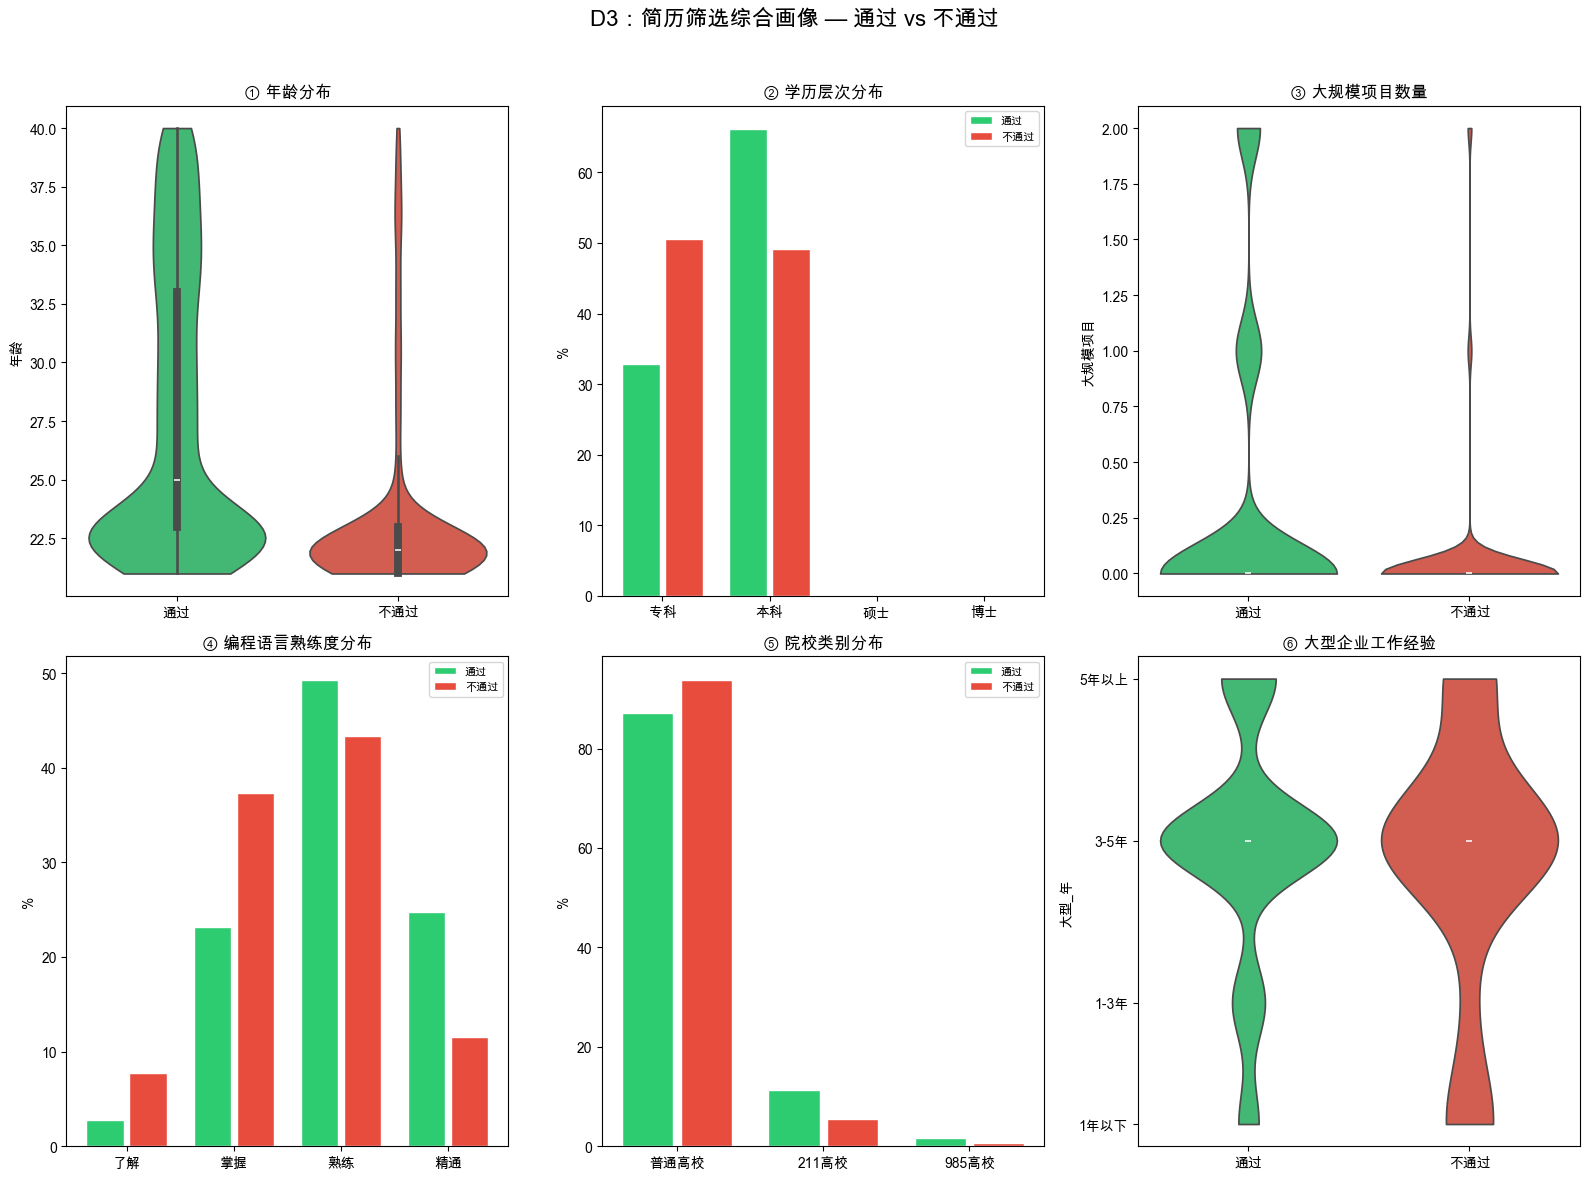

In [16]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('D3：简历筛选综合画像 — 通过 vs 不通过', fontsize=16, fontweight='bold', y=0.98)

palette = {'通过': '#2ecc71', '不通过': '#e74c3c'}

# 子图1：年龄（小提琴图）
ax1 = fig.add_subplot(2, 3, 1)
sns.violinplot(data=df_clean, x='筛选结果', y='年龄', ax=ax1,
               palette=palette, inner='box', cut=0)
ax1.set_title('① 年龄分布', fontsize=12)
ax1.set_xlabel('')

# 子图2：学历（堆叠条形图）
ax2 = fig.add_subplot(2, 3, 2)
edu_order = ['专科', '本科', '硕士', '博士']
edu_pass = df_clean[df_clean['筛选结果']=='通过']['学历层次'].value_counts(normalize=True).reindex(edu_order, fill_value=0)
edu_fail = df_clean[df_clean['筛选结果']=='不通过']['学历层次'].value_counts(normalize=True).reindex(edu_order, fill_value=0)
x_pos = np.arange(len(edu_order))
ax2.bar(x_pos - 0.2, edu_pass.values*100, 0.35, label='通过', color='#2ecc71', edgecolor='white')
ax2.bar(x_pos + 0.2, edu_fail.values*100, 0.35, label='不通过', color='#e74c3c', edgecolor='white')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(edu_order)
ax2.set_ylabel('%')
ax2.set_title('② 学历层次分布', fontsize=12)
ax2.legend(fontsize=8)

# 子图3：大规模项目（小提琴图）
ax3 = fig.add_subplot(2, 3, 3)
sns.violinplot(data=df_clean, x='筛选结果', y='大规模项目', ax=ax3,
               palette=palette, inner='box', cut=0)
ax3.set_title('③ 大规模项目数量', fontsize=12)
ax3.set_xlabel('')

# 子图4：编程熟练度（分组条形图）
ax4 = fig.add_subplot(2, 3, 4)
prof_labels = ['了解', '掌握', '熟练', '精通']
prof_pass = df_clean[df_clean['筛选结果']=='通过']['主要编程熟练度'].value_counts(normalize=True).reindex(prof_labels, fill_value=0)
prof_fail = df_clean[df_clean['筛选结果']=='不通过']['主要编程熟练度'].value_counts(normalize=True).reindex(prof_labels, fill_value=0)
x_pos4 = np.arange(len(prof_labels))
ax4.bar(x_pos4 - 0.2, prof_pass.values*100, 0.35, label='通过', color='#2ecc71', edgecolor='white')
ax4.bar(x_pos4 + 0.2, prof_fail.values*100, 0.35, label='不通过', color='#e74c3c', edgecolor='white')
ax4.set_xticks(x_pos4)
ax4.set_xticklabels(prof_labels)
ax4.set_ylabel('%')
ax4.set_title('④ 编程语言熟练度分布', fontsize=12)
ax4.legend(fontsize=8)

# 子图5：院校类别（分组条形）
ax5 = fig.add_subplot(2, 3, 5)
school_order = ['普通高校', '211高校', '985高校']
sch_pass = df_clean[df_clean['筛选结果']=='通过']['院校类别'].value_counts(normalize=True).reindex(school_order, fill_value=0)
sch_fail = df_clean[df_clean['筛选结果']=='不通过']['院校类别'].value_counts(normalize=True).reindex(school_order, fill_value=0)
x_pos5 = np.arange(len(school_order))
ax5.bar(x_pos5 - 0.2, sch_pass.values*100, 0.35, label='通过', color='#2ecc71', edgecolor='white')
ax5.bar(x_pos5 + 0.2, sch_fail.values*100, 0.35, label='不通过', color='#e74c3c', edgecolor='white')
ax5.set_xticks(x_pos5)
ax5.set_xticklabels(school_order)
ax5.set_ylabel('%')
ax5.set_title('⑤ 院校类别分布', fontsize=12)
ax5.legend(fontsize=8)

# 子图6：大型企业经验（小提琴图）
ax6 = fig.add_subplot(2, 3, 6)
violin_data = df_clean[['筛选结果','大型_年']].dropna()
sns.violinplot(data=violin_data, x='筛选结果', y='大型_年', ax=ax6,
               palette=palette, inner='box', cut=0)
ax6.set_yticks([0.5, 2, 4, 6])
ax6.set_yticklabels(['1年以下', '1-3年', '3-5年', '5年以上'])
ax6.set_title('⑥ 大型企业工作经验', fontsize=12)
ax6.set_xlabel('')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**结果解读：** 综合画像揭示了「通过」求职者的典型特征：年龄分布略偏年轻（集中在 25–32 岁）；学历以本科和硕士为主但硕士比例更高；大规模项目数量明显多于不通过组；编程熟练度更集中在「熟练」和「精通」；985/211 院校比例更高；在有大型企业经验的人中通过率更高。这些发现共同描绘出「高质量技术求职者」的画像——学历背景强、技能深度高、有重量级项目和大企业经历。